# The matter-wave microscope

In this tutorial, we are going to demonstrate the working principles behind the [matter-wave microscope](https://www.nature.com/articles/s41586-021-04011-2), and see how it can be used to magnify the density profile of atomic Bose-Einstein condensates (BECs).

## Introduction

One of the challenges arising when studying BECs in optical lattices is the diffraction limit: Most optical lattices have very short lattice spacing, requiring extremely high numerical apertures to be properly imaged. These high apertures are usually not even sufficient in the case of arrays of cylindrical BECs, as the depth of view is limited. One method to overcome these limitations is the matter-wave microscope.

The matterwave microscope uses harmonic traps to realise transformation of the atomic wavefunctions equivalent to the effect of lenses on electromagnetic fields. This can be understood readily by noticing that a quarter-period evolution in a harmonic trap of angular frequency $\omega$ as the same effect on the wavefunction $\psi (t = 0)$ that of a Fourier transform.

Let's demonstrate this with some simple simulations. We are going to simulate the evolution of a gaussian wavepacket with various parameters and see what happens over a quarter-period in an harmonic trap.


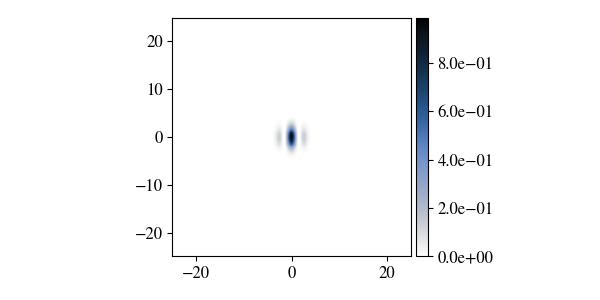

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from bloch_schrodinger.potential import Potential, create_parameter
from bloch_schrodinger.plotting import plot_eigenvector
from BECs.ssfm import SSFM
from BECs.potentialT import PotentialT
from BECs.ufuncs import gaussian2D



%matplotlib widget

### ----------------------
# Setting up the potential

s = 50 # simulation box size
resolution = (256,256) # Simulation box resolution

harmonic_trap = Potential( # For now, we only need a simple Potential object
    unitvecs=[[s, 0], [0, s]], # A square box of side s
    resolution=resolution,
    v0 = 0
)

T = 20 # Period, in arbitrary time unit
omega = 2 * np.pi / T # angular frequency of the trap

harmonic_trap.set( # We set the potential profile
    (harmonic_trap.x**2 + harmonic_trap.y**2) * omega**2 / 2
)

### ----------------------
# Setting up initial wavepacket, with a few parameter dimensions

k = create_parameter("k", np.linspace(1,3, 3)) # Initial wave-vector of the packet
sigma = create_parameter("sigma", np.linspace(2, 4, 2)) # Initial wavepacket width

psi0 = gaussian2D( # The initial wavepacket is a superposition of two gaussian wavepacket with a opposite wavevectors k and -k
    harmonic_trap.x, harmonic_trap.y,
    x0 = 0, y0 = 0,
    sigmax= sigma, sigmay=sigma,
    amp = 1
) * np.cos(harmonic_trap.x * k)

# We can use the plot_eigenvector function to plot the mode profile

plot_eigenvector(
    [[abs(psi0)**2]], [[None]], [['amplitude']]
)
plt.show()

Now we can simulate the time-evolution of this wavepacket. Using the Gross-Pitaevskii equation here, when there is no interactions is very much overkill, but in real systems, the interactions cannot always be suppressed.

In [2]:
g = 0 # Interactions
t_init = 0
t_final = T / 4 # We are going to simulate a quarter period evolution

t_samples = create_parameter('t', np.linspace(t_init, t_final, 50)) # We are going to save 50 time points

foo = SSFM(
    potential = harmonic_trap, psi0 = psi0, g = 0
)

psi = foo.solve(
    t_init, t_final, t_samples, parallelize=True, n_cores=6 # We are going to parallelize on 6 cores, if your machine does not support it, feel free to lower n_cores
)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    2.8s remaining:    2.8s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    3.0s finished


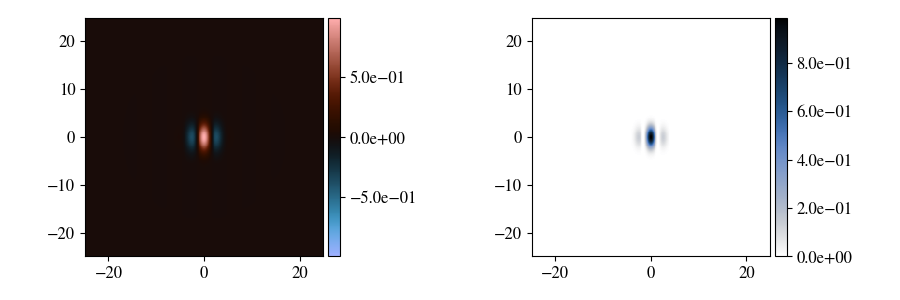

In [3]:
plot_eigenvector(
    [[psi.real, abs(psi)**2]], [[None]*2], [['real', 'amplitude']]
)
plt.show()

We can clearly see here that at the end of the quarter period, the wavepacket has been fully converted to its Fourier transform. Larger wavepackets in real space are more localized in k-space, in agreement with the Heisenberg principle, and higher k-components are further away from the origin.

It is also straightforward to understand that a stronger harmonic trap will lead to a smaller k-space, and vice-versa. From this, it follows easily that a stronger harmonic trap can be represented by a convergent lense of smaller focal length. Thus, if one chains two quarter-period evolutions in traps of frequencies $\omega_1$ and $\omega_2$, one can realise the equivalent of a 4f telescope with a magnification factor of $M = -\omega_1 / \omega_2$. Let's demonstrate this now, using the same initial state $\psi_0$.

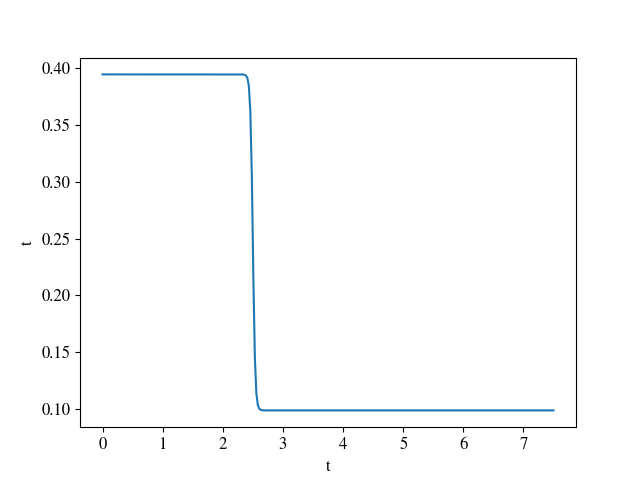

In [4]:
telescope = PotentialT( # We now use a PotentialT object
    unitvecs=[[s, 0], [0, s]],
    resolution=resolution,
    v0 = 0
)

T1 = 10
T2 = 20
w1 = 2*np.pi/T1
w2 = 2*np.pi/T2

t_final = T1/4 + T2/4

telescope.add_shape('trap', (telescope.x**2 + telescope.y**2) / 2) # A normalized harmonic trap is added to the shape context of the telescope 
telescope.step('step', ts = T1/4, sigma = T1/100, vi = w1**2, vf = w2**2) # A time-step function is added, controling the switch between trapping frequencies

telescope.add_term('step * trap')

telescope.plot_timefunction('step', tmin = 0, tmax = t_final, n_t=300)
plt.show()

In [5]:
t_samples = create_parameter('t', np.linspace(t_init, t_final, 99)) # We are going to save 99 time points

bar = SSFM(
    potential = telescope, psi0 = psi0, g = 0
)

psi = bar.solve(
    t_init, t_final, t_samples, parallelize=True, n_cores=6
)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    4.9s remaining:    4.9s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    5.3s finished


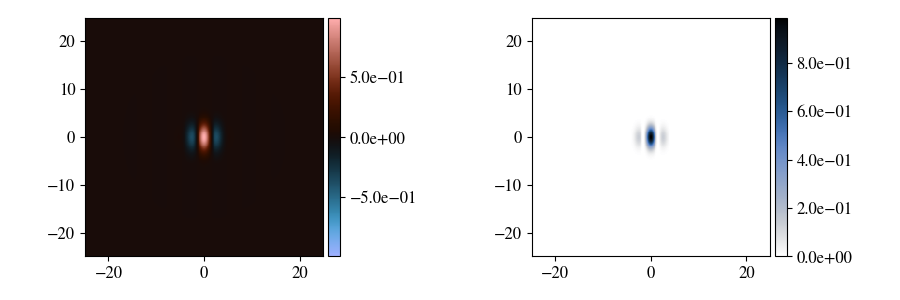

In [6]:
plot_eigenvector(
    [[psi.real, abs(psi)**2]], [[None]*2], [['real', 'amplitude']]
)
plt.show()

The final state $\psi(t = T_1 / 4 + T_2 / 4)$ is indeed a magnified version of the original state, with a further $\pi$-phaseshift added. Numerically-speaking, we have performed a very inefficient interpolation and cropping of our original states.

## Higher-band resolutions
Wang et al.
Thanks to the large magnifications accessible with the matter-wave microscope, it can be used to resolve intra-site details of optical lattices. Here, we build a simple example simulation of such situation.

Inspired by [[Wang2021]](https://www.nature.com/articles/s41586-021-03702-0), we are going to demonstrate the magnification of an s-p hybrid state in a honeycomb lattice with a large sublattice energy offset.

First, we simulate a single lattice unit cell.


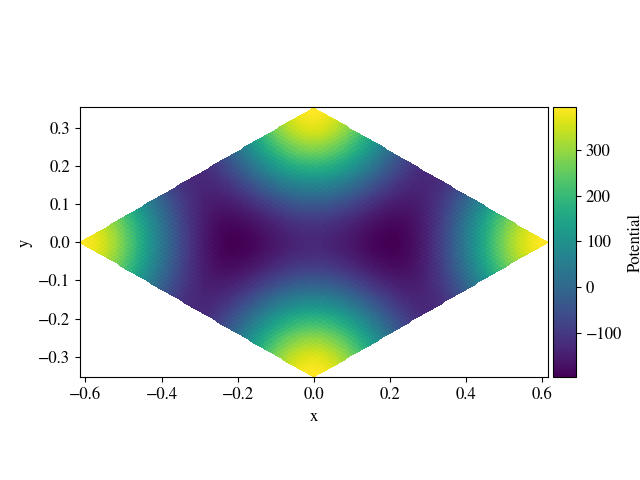

In [17]:
from bloch_schrodinger.potential import optical_honeycomb, make_optical_honeycomb

wavelength = 1.064

delta = 0.9*0
s = 7.5
s1 = s - delta
s2 = s + delta

cst, honeycomb = optical_honeycomb( # A high level function to directly construct an optical honeycomb lattice
    wavelength, s1 = s1, s2 = s2
)


honeycomb.plot()
plt.show()


It is possible, using an energy offset sweep, to prepare a condensaet in the second band of the optical lattice. In this band, the condesnate localizes either at the K or K' point, breaking time-reversal symmetry thanks to interactions. We are going to directly compute the state profile from the Bloch-Scrödinger equation, which is much easier numerically speaking.

In [18]:
from bloch_schrodinger.fdsolver import FDSolver

foo = FDSolver(
    potentials= honeycomb, alphas = 0.5
)

# Solving at the K point
foo.kx = cst['K'][0]
foo.ky = cst['K'][1]

eigva, eigve = foo.solve(n_eigva=3)
# eigve *= np.exp(-1j * (foo.kx * eigve.x + foo.ky * eigve.y))


Performing 1 diagonalizations...


100%|██████████| 1/1 [00:00<00:00,  5.43it/s]


storing the results


100%|██████████| 1/1 [00:00<00:00, 2623.08it/s]


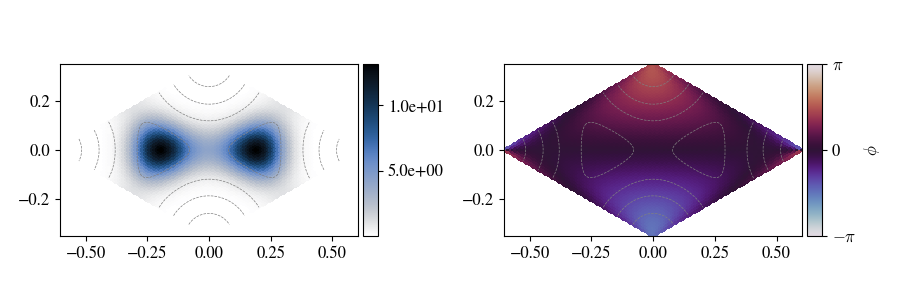

In [25]:
import xarray as xr

psi0_uc = eigve

plot_eigenvector( 
    [[abs(psi0_uc)**2, xr.ufuncs.angle(psi0_uc)]],
    [[honeycomb]*2],
    [['amplitude', 'phase']]
)

plt.show()

# The bloch eigenfunction present a px +/- 1j*py vortex orbital on the A sublattice, and a s-orbital on the B sublattice

Now, we are going to take this mode profile and reproduce it on a very large rectangular grid for the time-evolution simulation.

/home/martin-guillot/Documents/MyLibraries/bloch_schrodinger/bloch_schrodinger/plotting.py:707: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  obj = func(ax,
/home/martin-guillot/Documents/MyLibraries/bloch_schrodinger/bloch_schrodinger/plotting.py:707: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  obj = func(ax,


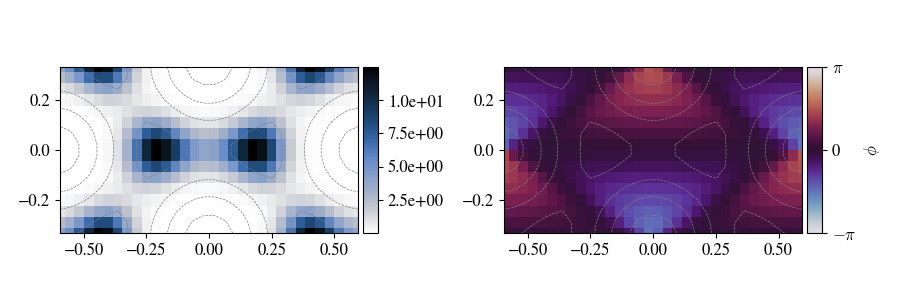

In [26]:
from bloch_schrodinger.utils import tile

fin_res = 1024 #The final resolution of the full grid
n_x = 32 # Number of double unit cells along x
n_y = 64 # Number of double unit cells along y 

# First we tile psi0_uc on multiple unit cells
psi0_ext = tile(psi0_uc, [cst['a1'], cst['a2']], bounds1=[-1, 2], bounds2=[-1, 2])
honey_ext = honeycomb.tile(bounds1=[-1, 2], bounds2=[-1, 2])

a1_square = cst['a1'] + cst['a2']
a2_square = cst['a1'] - cst['a2']

honey_square = Potential(
    unitvecs=[a1_square, a2_square],
    resolution=(fin_res//n_x, fin_res//n_y),
    v0 = 0
)

cst, honey_square = make_optical_honeycomb(honey_square, wavelength, s1, s2)

# We now construct a map linking each point of the square grid to a point in the triangular grid coordinates
M = np.array([cst['a1'], cst['a2']])
M = np.linalg.inv(M).T

vec1, vec2 = M[0], M[1]
rev_a1 = (vec1[0] * honey_square.x + vec1[1] * honey_square.y)
rev_a2 = (vec2[0] * honey_square.x + vec2[1] * honey_square.y)

# We use the interpolate function from xarray
psi0_square = psi0_ext.interp(a1 = rev_a1, a2 = rev_a2)

plot_eigenvector(
    [[abs(psi0_square)**2, xr.ufuncs.angle(psi0_square)]],
    [[honey_square]*2],
    [['amplitude', 'phase']]
)

plt.show()

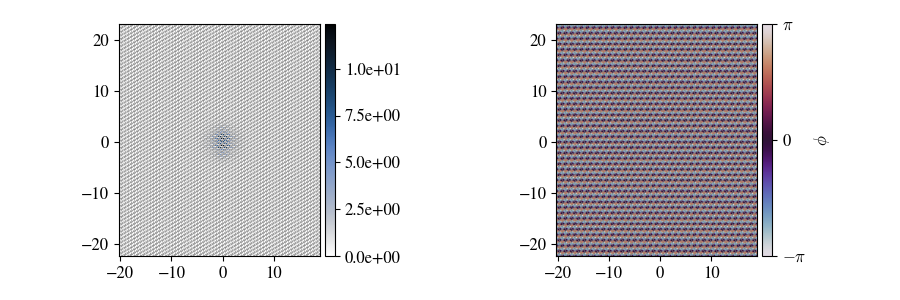

In [27]:
# Now we extend this state to a large lattice, without forgeting the plane wave to get the actual eigenvector and not the bloch eigenvector

sigma = 2.5
psi0 = tile(psi0_square, [a1_square, a2_square], (-n_x//2, n_x//2), (-n_y//2, n_y//2))
psi0 *= gaussian2D(psi0.x, psi0.y, 0, 0, sigma, sigma, 1)
psi0 *= np.exp(-1j * (foo.kx * psi0.x + foo.ky * psi0.y))


honey_large = honey_square.tile((-n_x//2, n_x//2), (-n_y//2, n_y//2))

plot_eigenvector(
    [[abs(psi0)**2, xr.ufuncs.angle(psi0)]],
    [[honey_large]*2],
    [['amplitude', 'phase']],
    ncontours=1
)

plt.show()

We are now ready for our microscopy protocol

/home/martin-guillot/Documents/MyLibraries/bloch_schrodinger/bloch_schrodinger/plotting.py:290: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(**figkw)


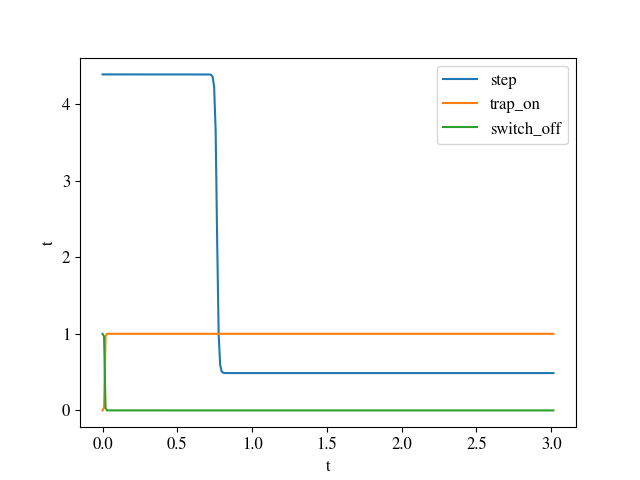

In [28]:
microscope = PotentialT.fromPotential(honey_large)

T1 = 3
T2 = 9
w1 = 2*np.pi/T1
w2 = 2*np.pi/T2


t_i = 0 
t_s = T1/200
t_f = T1/4 + T2/4 + t_s

microscope.step("switch_off", t_s, T1/400, 1, 0) # switch-off of the lattice

microscope.step("trap_on", t_s, T1/400, 0, 1) # Switch-on of the harmonic trap
microscope.add_shape('trap', (microscope.x**2 + microscope.y**2) / 2) # The harmonic trap 
microscope.step('step', ts = T1/4 + t_s, sigma = T1/100, vi = w1**2, vf = w2**2) # switch between trapping frequencies

microscope.add_term('step * trap_on * trap')
microscope.modulate('switch_off')

microscope.plot_timefunction(['step', 'trap_on', 'switch_off'], tmin = t_i, tmax = t_f, n_t=300)
plt.show()

In [ ]:
bar = SSFM(microscope, psi0, 0)

t_samples = create_parameter('t', np.linspace(t_i, t_f, 99)) # We are going to save 99 time points


psi = bar.solve(
    t_init=t_i,
    t_final=t_f,
    t_samples=t_samples,
    verbose = False,
    parallelize=True,
    n_cores=6
)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


 99%|█████████▉| 2.981/3.015, 35.64s/it, [01:46 < 00:01]    
 99%|█████████▉| 2.989/3.015, 35.73s/it, [01:46 < 00:00]
 99%|█████████▉| 2.980/3.015, 36.17s/it, [01:47 < 00:01]


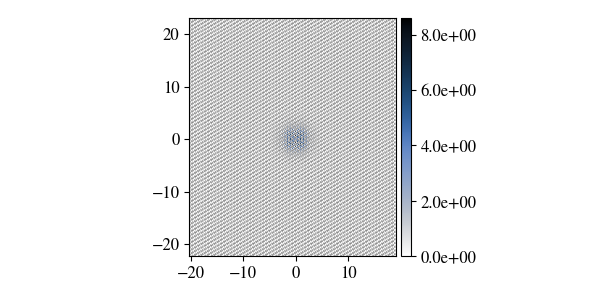

In [ ]:
plot_eigenvector(
    [[abs(psi)**2]],
    [[microscope.to_potential(t_samples)]],
    [['amplitude']],
    # [[psi.real]],
    # [[microscope.to_potential(t_samples)]],
    # [['real']],
    ncontours=1
)

plt.show()

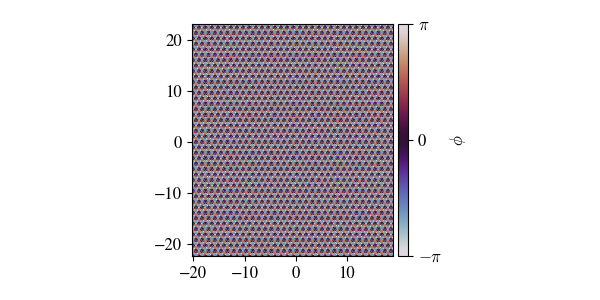

In [15]:
plot_eigenvector(
    [[xr.ufuncs.angle(psi)]],
    [[microscope.to_potential(t_samples)]],
    [['phase']],
    ncontours=1
)

plt.show()

In [16]:
T1/4

0.75